# Analisis y visualización.

**Descripción**.

Realizar un análisis y visualización de los resultados numéricos.

<a href="https://github.com/luiggix/RTWMA">RTWMA</a> © 2024-2026 by <a href="https://www.geofisica.unam.mx">IGF-UNAM</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc/4.0/">CC BY-NC 4.0</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">

In [1]:
import flopy
import numpy as np
import matplotlib.pyplot as plt
import xmf6
from src_gypsum import vis

In [2]:
# Usamos LaTeX para los tectos de la figura.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  
    "font.serif": ["Computer Modern Roman"],
})

## Coordenadas del dominio.

In [5]:
# Cargamos el modelo de flujo
o_sim = flopy.mf6.MFSimulation.load(
    sim_ws="io_mf6/gwf_dfc_wma",
    verbosity_level=0)

# Obtenemos el objetos del modelo
o_gwf = o_sim.get_model("flow")

# Recuperamos las coordenadas del dominio
grid = o_gwf.modelgrid

# Recuperamos las coordenadas de los centros de las celdas de la malla
x = grid.xcellcenters[0] # centros de los volúmenes
print(x)

[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]


## Resultados del transporte reactivo

In [10]:
# Generados con GWT
c_gwt = vis.data_recovery("nr_analysis/gypsum_eq_gwt.out")
# Generados con DFC
c_dfc = vis.data_recovery("nr_analysis/gypsum_eq_dfc.out")
# Datos para comparación (numéricos y analíticos)
c1, c2, an_c1, an_c2 = vis.data_recovery_excel("nr_analysis/comparativa_02.xlsx")

## Cálculo del error.
$$
{\displaystyle \operatorname {RMSE} ={\sqrt {{\frac {1}{n}}\sum _{i=1}^{n}(X_{i}-x_{0})^{2}}}}.
$$

$$
 {\displaystyle {\mbox{MAPE}}=100{\frac {1}{n}}\sum _{t=1}^{n}\left|{\frac {A_{t}-F_{t}}{A_{t}}}\right|}
$$

In [11]:
# GWT error
#
# Calculamos el RMSE (https://en.wikipedia.org/wiki/Root_mean_square_deviation)
RMSE1_gwt = np.linalg.norm(an_c1 - c_gwt[0]) / np.sqrt(len(c_gwt[0]))
RMSE2_gwt = np.linalg.norm(an_c2 - c_gwt[1]) / np.sqrt(len(c_gwt[1]))
#
# Calculamos el MAPE (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)
MAPE1_gwt = np.mean(np.abs((an_c1 - c_gwt[0]) / an_c1)) * 100
MAPE2_gwt = np.mean(np.abs((an_c2 - c_gwt[1]) / an_c2)) * 100

xmf6.nice_print("GWT Error")
print(f"RMSE c1: {RMSE1_gwt:5.2e} \t RMSE c2: {RMSE2_gwt:5.2e}")
print(f"MAPE c1: {MAPE1_gwt:5.2f}% \t MAPE c2: {MAPE2_gwt:5.2f}")

# DFC error
#
# Calculamos el RMSE (https://en.wikipedia.org/wiki/Root_mean_square_deviation)
RMSE1_dfc = np.linalg.norm(an_c1 - c_dfc[0]) / np.sqrt(len(c_dfc[0]))
RMSE2_dfc = np.linalg.norm(an_c2 - c_dfc[1]) / np.sqrt(len(c_dfc[1]))
#
# Calculamos el MAPE (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)
MAPE1_dfc = np.mean(np.abs((an_c1 - c_dfc[0]) / an_c1)) * 100
MAPE2_dfc = np.mean(np.abs((an_c2 - c_dfc[1]) / an_c2)) * 100

xmf6.nice_print("DFC Error")
print(f"RMSE c1: {RMSE1_dfc:5.2e} \t RMSE c2: {RMSE2_dfc:5.2e}")
print(f"MAPE c1: {MAPE1_dfc:5.2f}% \t MAPE c2: {MAPE2_dfc:5.2f}")


GWT Error
―――――――――

RMSE c1: 1.48e+00 	 RMSE c2: 3.45e-06
MAPE c1: 14.97% 	 MAPE c2: 12.43

DFC Error
―――――――――

RMSE c1: 1.48e+00 	 RMSE c2: 3.45e-06
MAPE c1: 14.97% 	 MAPE c2: 12.43


## Visualización de los resultados.

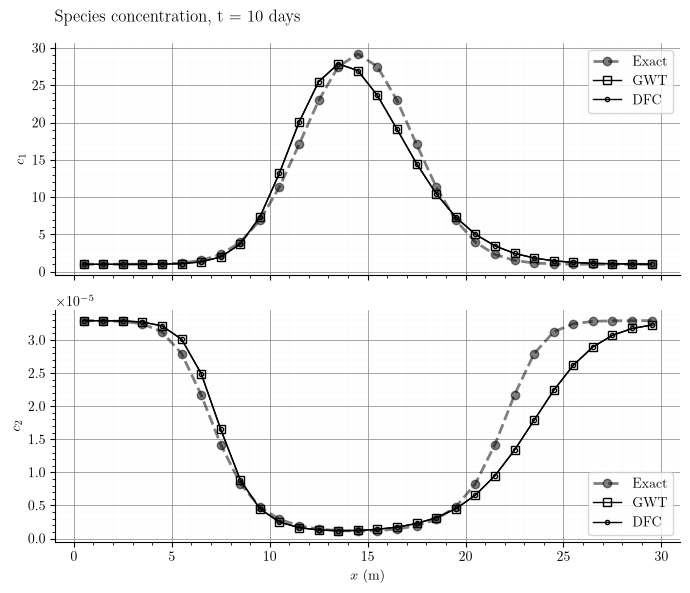

In [12]:
vis.plot(x, (an_c1, an_c2), (c_gwt, c_dfc), 
         ("s-", ".-"), ("GWT", "DFC"), savefig = "gyp.pdf")